# Introduction

Trie, also called prefix tree, is a special form of a Nary tree.

After completing this card, you should be able to:

1. Understand the concept of Trie;
2. Do insertion and search operations in a Trie;
3. Understand how Trie helps in practical application;
4. Solve practical problems using Trie.

# Trie Structure
A trie (pronounced “try”), also called a prefix tree, is a tree-like data structure used to store a set of strings where each node represents a character, and paths from the root represent prefixes of those strings.
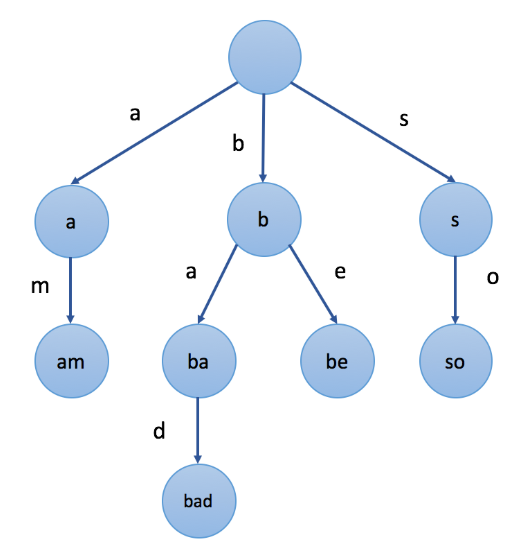
It allows efficient operations like insertion, search, and prefix matching—typically in time proportional to the length of the word rather than the number of stored words.

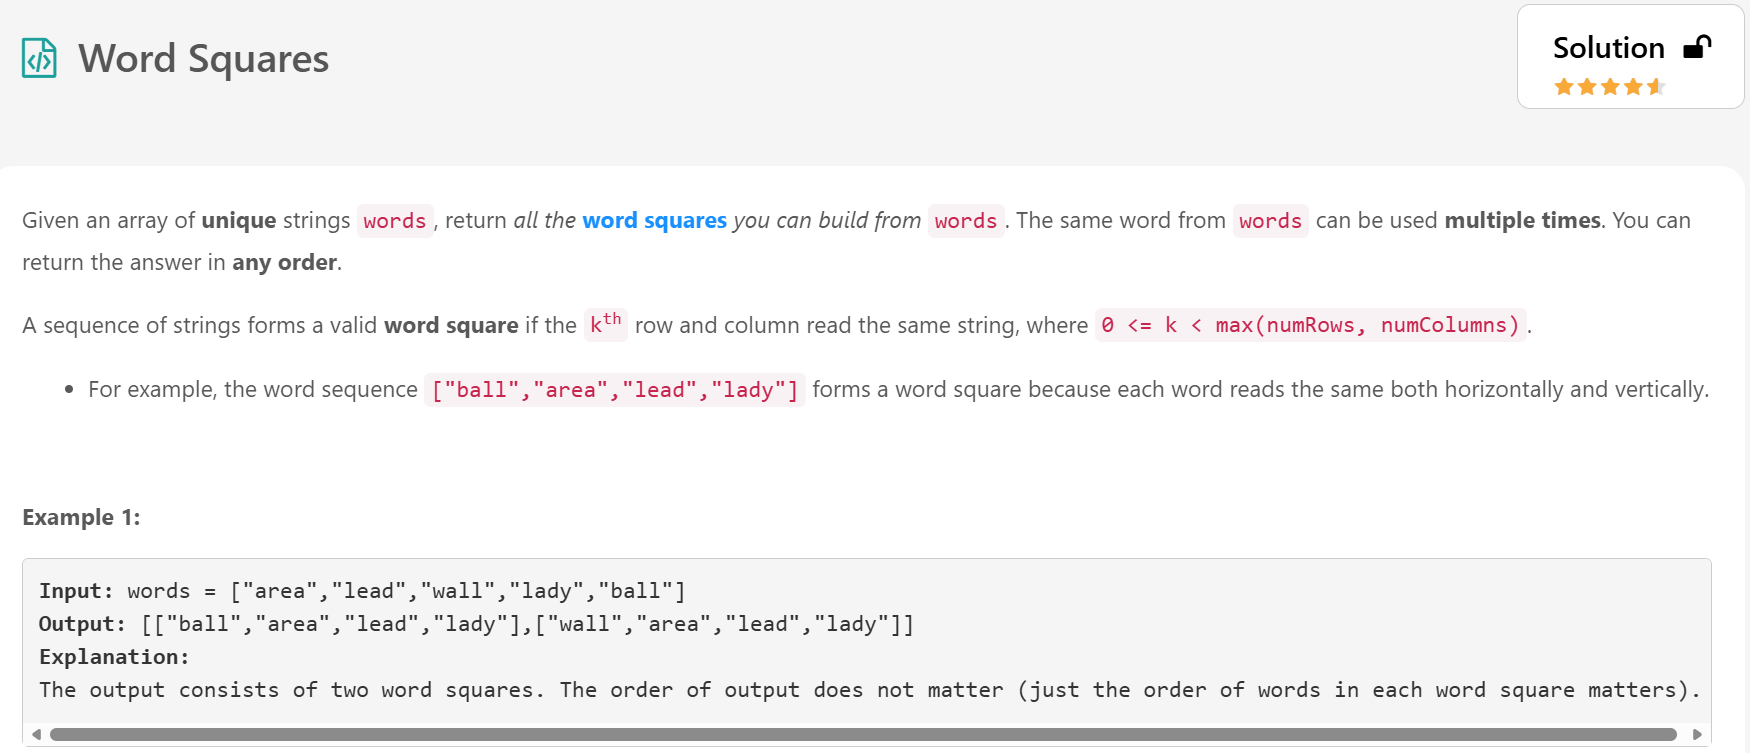

1. 预处理 prefix_map
2. 从每个 word 开始作为第一行
3. 每一层根据当前列生成 prefix
4. 从 prefix_map[prefix] 找候选词
5. 回溯尝试
6. 长度达到 n 时加入答案
```python
class Solution(object):
    def wordSquares(self, words):
        """
        :type words: List[str]
        :rtype: List[List[str]]
        """
        n = len(words[0])
        prefix_map = defaultdict(list)
        
        for word in words:
            for i in range(n+1):
                prefix = word[:i]
                prefix_map[prefix].append(word)
                
        
        res = []
        
        def backtrack(square):
            if len(square) == n:
                res.append(square[:])
                return
            
            row = len(square)
            
            prefix = ""
            for word in square:
                prefix += word[row]
                
            for candidate in prefix_map[prefix]:
                square.append(candidate)
                backtrack(square)
                square.pop()
                
        for word in words:
            backtrack([word])
            
        return res
```

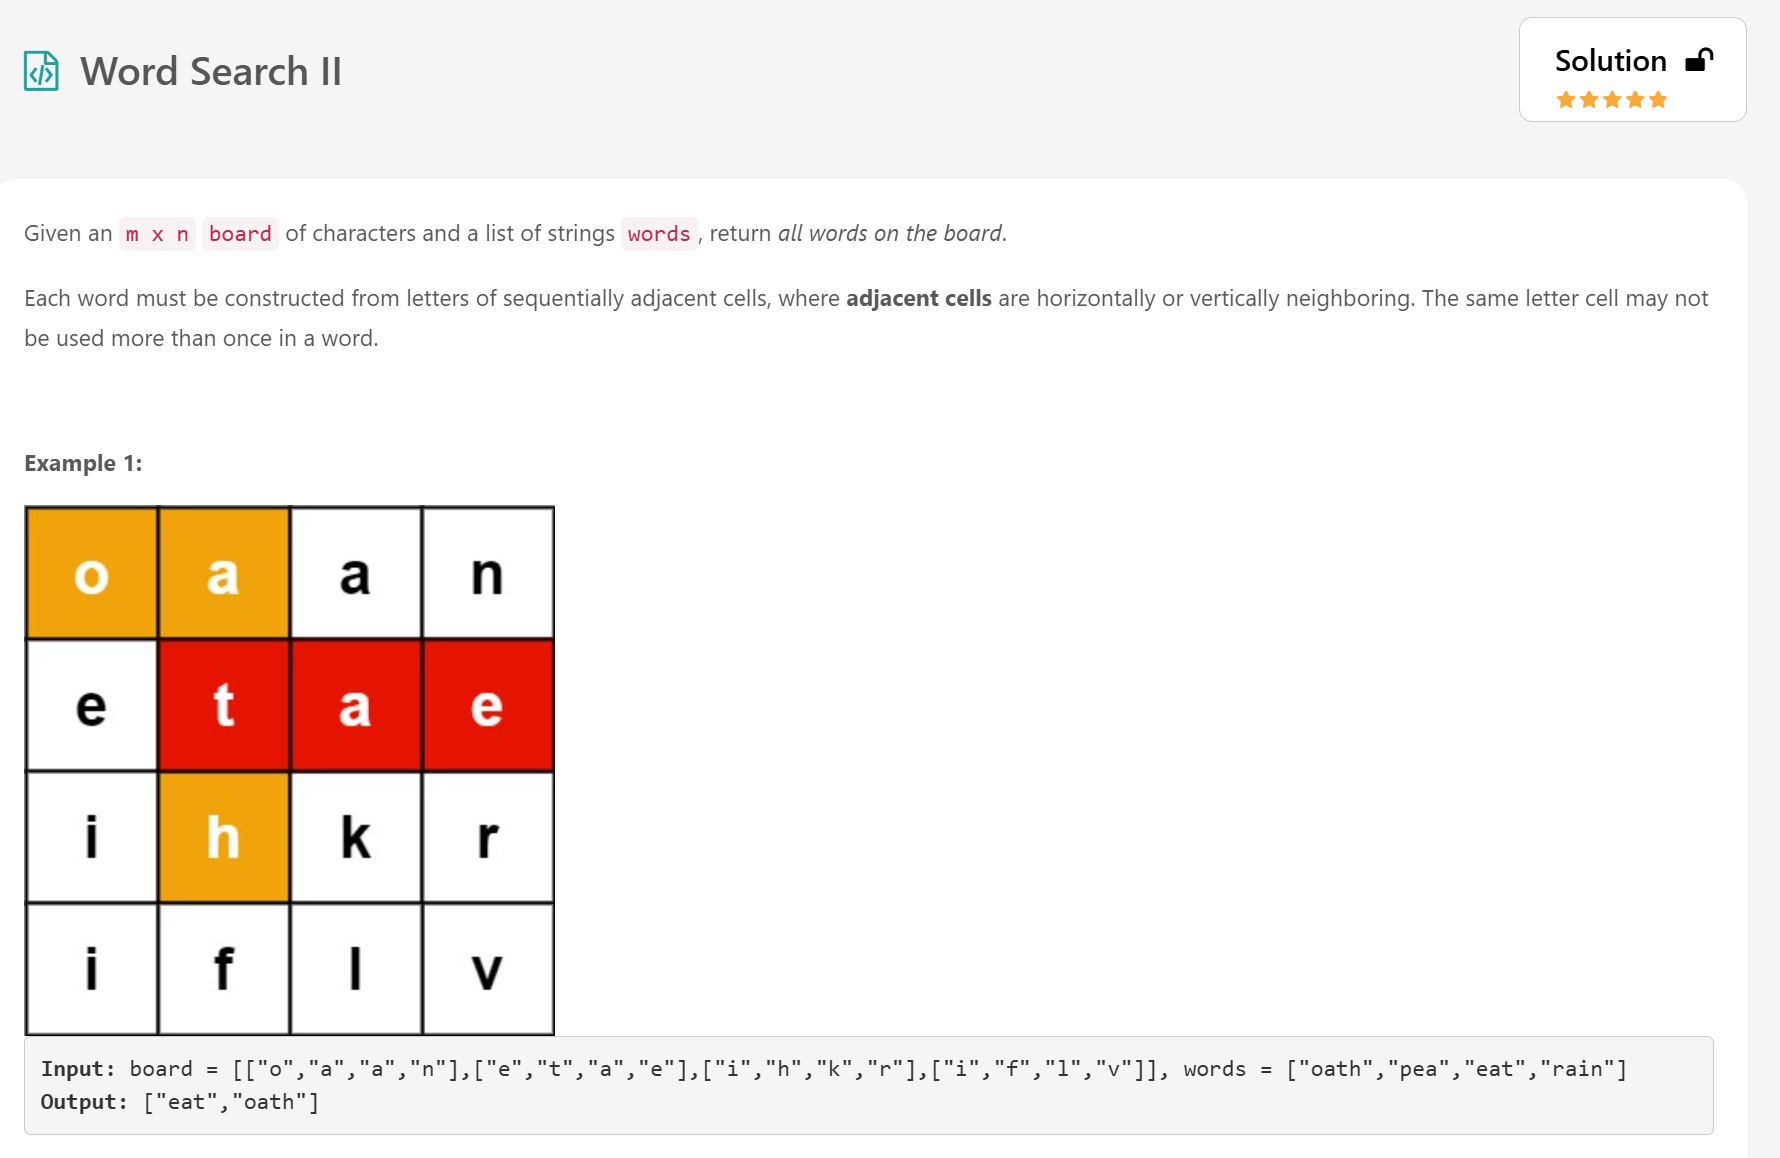

```python
class TrieNode:
    def __init__(self):
        self.children = {}
        self.word = None
        
class Solution(object):
    def findWords(self, board, words):
        """
        :type board: List[List[str]]
        :type words: List[str]
        :rtype: List[str]
        """
        root = TrieNode()
        
        for word in words:
            node = root
            for char in word:
                if char not in node.children:
                    node.children[char] = TrieNode()
                node = node.children[char]
                
            node.word = word
            
        m, n =len(board), len(board[0])
        res = []
        
        directions = [(1,0),(-1,0),(0,1),(0,-1)]
        
        def dfs(i,j,node):
            char = board[i][j]
            
            if char not in node.children:
                return
            
            nxt_node = node.children[char]
            
            if nxt_node.word is not None:
                res.append(nxt_node.word)
                nxt_node.word = None
                
            
            board[i][j] = "#"
            
            for di, dj in directions:
                nxt_i, nxt_j  = i + di, j + dj
                if 0 <= nxt_i < m and 0 <= nxt_j < n and board[nxt_i][nxt_j] != "#":
                    dfs(nxt_i,nxt_j,nxt_node)
                        
            board[i][j] = char
            
            if not nxt_node.children and nxt_node.word is None:
                del node.children[char]
                
            return
                
        for i in range(m):
            for j in range(n):
                dfs(i,j,root)
                
        return res
                
```